# Importing

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import pickle
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    accuracy_score, 
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
from sklearn.model_selection import RandomizedSearchCV

# Preprocessing

### Section A - Config 

In [34]:
THRESHOLD = 0.5
MODEL_DIR = "behavioral_model"
SPLIT_RATIO = 0.8

### Section B – Basic Preprocessing

In [35]:
COLUMNS_TO_DROP = [
    'transaction_id',
    'anomaly_types',
    'created_at',
    'updated_at',
    'bill_date',
    'business_date',
    'rule_id',
    'rule_type',
    'item_code',
    'sku_category_code',
    'category_code',
    'store_id',
    'activity_id',
    'funding_partner_id'
]

In [36]:
def basic_preprocess(df):
    df = df.copy()
    df = df.drop(columns=COLUMNS_TO_DROP, errors="ignore")
    
    df["transaction_date"] = pd.to_datetime(df["transaction_date"])
    
    df["hour"] = df["transaction_date"].dt.hour
    df["day_of_week"] = df["transaction_date"].dt.dayofweek
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
    
    return df

### Section C - Sorting

In [37]:
def sort_by_user_time(df):
    
    df = df.copy()
    
    df = df.sort_values(
        by=["customer_unique_id", "transaction_date"]
    ).reset_index(drop=True)
    
    return df

### Section D - Split by Per-User Chronological Split

In [38]:
def split_per_user(df, split_ratio: float = 0.8):
    
    train_parts = []
    val_parts = []
    
    for _, group in df.groupby("customer_unique_id"):
        
        n = len(group)
        
        if n == 1:
            train_parts.append(group)
            continue
        
        if n == 2:
            train_parts.append(group.iloc[:1])
            val_parts.append(group.iloc[1:])
            continue
        
        cutoff = int(np.floor(n * split_ratio))
        
        cutoff = max(1, min(cutoff, n - 1))
        
        train_parts.append(group.iloc[:cutoff])
        val_parts.append(group.iloc[cutoff:])
    
    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    
    return train_df, val_df

# Behavioral Feature Engineering Module

In [ ]:
def add_behavioral_features(df):
    
    df = df.copy()
    df = df.sort_values(
        by=["customer_unique_id", "transaction_date"]
    )
    
    
    df["prev_transaction_time"] = (
        df.groupby("customer_unique_id")["transaction_date"]
        .shift(1)
    )
    
    df["time_since_last_transaction"] = (
        df["transaction_date"] - df["prev_transaction_time"]
    ).dt.total_seconds()
    
    df = df.set_index("transaction_date")
    
    df["transactions_last_10_min"] = (
        df.groupby("customer_unique_id")
          .rolling("10min")["amount"]
          .count()
          .shift(1)
          .values
    )
    
    df["transactions_last_1h"] = (
        df.groupby("customer_unique_id")["customer_unique_id"]
        .rolling("1h")
        .count()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    
    df["transactions_last_24h"] = (
        df.groupby("customer_unique_id")["customer_unique_id"]
        .rolling("24h")
        .count()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    
    df = df.reset_index()
    
    df["user_avg_amount"] = (
        df.groupby("customer_unique_id")["amount"]
        .expanding()
        .mean()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    
    df["amount_to_user_avg_ratio"] = (
        df["amount"] / df["user_avg_amount"]
    )
 
    df["user_std_amount"] = (
        df.groupby("customer_unique_id")["amount"]
        .expanding()
        .std()
        .shift(1)
        .reset_index(level=0, drop=True)
    )
    
    # df["z_score_amount"] = (
    #     (df["amount"] - df["user_avg_amount"]) /
    #     df["user_std_amount"]
    # )
    
    df["balance_depletion_ratio"] = (
        df["points"] / df["opening_balance"]
    )
    
    
    # Cleanups    
    df["time_since_last_transaction"] = df["time_since_last_transaction"].fillna(-1)
    df["transactions_last_1h"] = df["transactions_last_1h"].fillna(0)
    df["transactions_last_24h"] = df["transactions_last_24h"].fillna(0)
    df["user_avg_amount"] = df["user_avg_amount"].fillna(0)
    df["user_std_amount"] = df["user_std_amount"].fillna(0)
    df["amount_to_user_avg_ratio"] = df["amount_to_user_avg_ratio"].replace([np.inf, -np.inf], 0).fillna(0)
    # df["z_score_amount"] = df["z_score_amount"].replace([np.inf, -np.inf], 0).fillna(0)
    df["balance_depletion_ratio"] = df["balance_depletion_ratio"].replace([np.inf, -np.inf], 0).fillna(0)
    
    # Optional: drop helper columns
    df = df.drop(columns=["prev_transaction_time", "user_std_amount"], errors="ignore")
    
    return df

# Post-Feature Cleanup

In [ ]:
def finalize_features(df, drop_target=False):
    
    df = df.copy()
    
    df = df.drop(
        columns=["transaction_date", "customer_unique_id"],
        errors="ignore"
    )
    
    if drop_target and "is_anomaly" in df.columns:
        df = df.drop(columns=["is_anomaly"])
    
    df = df.replace([np.inf, -np.inf], 0)
    df = df.fillna(0)
    
    return df

# Model Training Module

### Training

In [ ]:
def train_catboost(train_df,val_df,model_prefix):
    
    y_train = train_df["is_anomaly"]
    X_train = train_df.drop(columns=["is_anomaly"])
    
    y_val = val_df["is_anomaly"]
    X_val = val_df.drop(columns=["is_anomaly"])
    
    feature_cols = X_train.columns.tolist()
    
    with open(f"{MODEL_DIR}/{model_prefix}_feature_cols.pkl", "wb") as f:
        pickle.dump(feature_cols, f)
    
    cat_cols = X_train.select_dtypes(include=["str", "object"]).columns
    
    with open(f"{MODEL_DIR}/{model_prefix}_cat_cols.pkl", "wb") as f:
        pickle.dump(cat_cols, f)
    
    scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    
    model = CatBoostClassifier(
        class_weights=[1, scale_weight],
        verbose=1
    )
    
    model.fit(
        X_train,
        y_train,
        cat_features=cat_cols.tolist()
    )

    model.save_model(f"{MODEL_DIR}/{model_prefix}_model.cbm")

    
    print(f"\n{model_prefix.upper()} Behavioral Model Trained")
    
    
    return model, X_val, y_val

### Metrics

In [42]:
from scipy.stats import ks_2samp

def print_metrics(model, X_val, y_val, model_prefix):
    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = (y_prob > THRESHOLD).astype(int)
    
    roc_auc = roc_auc_score(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)
    f1 = f1_score(y_val, y_pred)
    gini = 2 * roc_auc - 1
    ks = ks_2samp(y_prob[y_val==0], y_prob[y_val==1]).statistic
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred).tolist()
    
    metrics = {
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "Gini": gini,
        "KS": ks,
        "precision": precision,
        "recall": recall,
        "confusion_matrix": cm,
        "threshold": THRESHOLD
    }
    
    with open(f"{MODEL_DIR}/{model_prefix}_behavioral_metrics.pkl", "wb") as f:
        pickle.dump(metrics, f)
        
    print("Validation Metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v}")
        
    return y_prob, y_pred

### Decile

In [43]:
def decile_cal(y_val, y_prob, y_pred, model_prefix):
    decile_bins = np.percentile(y_prob, [10,20,30,40,50,60,70,80,90])
    
    with open(f"{MODEL_DIR}/{model_prefix}_behavioral_decile_bins.pkl", "wb") as f:
        pickle.dump(decile_bins, f)
    
    def assign_decile(prob, bins):
        for i, cutoff in enumerate(bins):
            if prob <= cutoff:
                return f"D{i+1}"
        return "D10"

    result_df = pd.DataFrame({
        "actual": y_val.values,
        "probability": y_prob,
        "predicted": y_pred
    })

    result_df["decile"] = result_df["probability"].apply(
        lambda x: assign_decile(x, decile_bins)
    )
    
    def assign_severity(decile):
        if decile == "D10":
            return "Very High Risk"
        elif decile in ["D8", "D9"]:
            return "High Risk"
        elif decile in ["D5", "D6", "D7"]:
            return "Medium Risk"
        else:
            return "Low Risk"

    result_df["severity"] = result_df["decile"].apply(assign_severity)
    
    ACTION_ORDER = ["Very High Risk", "High Risk", "Medium Risk", "Low Risk"]

    print("\nNon-Anomalies Distribution")
    good_table = (
        result_df[result_df["actual"] == 0]["severity"]
        .value_counts()
        .reindex(ACTION_ORDER, fill_value=0)
        .to_frame("Count")
    )
    good_table["%"] = (
        good_table["Count"] / good_table["Count"].sum() * 100
    ).round(2)
    print(good_table)

    print("\nAnomalies Distribution")
    bad_table = (
        result_df[result_df["actual"] == 1]["severity"]
        .value_counts()
        .reindex(ACTION_ORDER, fill_value=0)
        .to_frame("Count")
    )
    bad_table["%"] = (
        bad_table["Count"] / bad_table["Count"].sum() * 100
    ).round(2)
    print(bad_table)

    # Decile Performance Table
    decile_summary = (
        result_df.groupby("decile")
        .agg(
            total=("actual","count"),
            bad=("actual","sum")
        )
    )

    decile_summary["bad_rate"] = (
        decile_summary["bad"] / decile_summary["total"]
    ).round(4)

    print("\nDecile Performance Table")
    print(decile_summary.sort_index())
    
    return result_df

# Main Flow

### Accrual Data

### Load DF

In [44]:
accu_df = pd.read_csv("Datasets/synthetic_accural_data.csv")

### preprocess and training

In [ ]:
accu_df = basic_preprocess(accu_df)
accu_df = sort_by_user_time(accu_df)

train_accu, val_accu = split_per_user(accu_df, split_ratio=SPLIT_RATIO)

# train_accu = add_behavioral_features(train_accu)
# val_accu = add_behavioral_features(val_accu)

# train_accu = finalize_features(train_accu)
# val_accu = finalize_features(val_accu)

train_accu["__is_train"] = 1
val_accu["__is_train"] = 0

full_df = pd.concat([train_accu, val_accu], axis=0)
full_df = sort_by_user_time(full_df)
    
full_df = add_behavioral_features(full_df)
    
train_accu = full_df[full_df["__is_train"] == 1].drop(columns="__is_train")
val_accu   = full_df[full_df["__is_train"] == 0].drop(columns="__is_train")
    
train_accu = finalize_features(train_accu)
val_accu   = finalize_features(val_accu)

In [64]:
train_accu.to_csv("behavioral_train_val/train_accu.csv",encoding='utf-8', index=False)
val_accu.to_csv("behavioral_train_val/val_accu.csv",encoding='utf-8', index=False)

In [47]:
accu_model, accu_X_val, accu_y_val = train_catboost(train_accu, val_accu, "accu_behavioral")

Learning rate set to 0.022069
0:	learn: 0.6598062	total: 33.3ms	remaining: 33.3s
1:	learn: 0.6347961	total: 54.7ms	remaining: 27.3s
2:	learn: 0.6092950	total: 92.1ms	remaining: 30.6s
3:	learn: 0.5853815	total: 129ms	remaining: 32.1s
4:	learn: 0.5639311	total: 165ms	remaining: 32.9s
5:	learn: 0.5449398	total: 203ms	remaining: 33.5s
6:	learn: 0.5295351	total: 227ms	remaining: 32.2s
7:	learn: 0.5111325	total: 266ms	remaining: 33s
8:	learn: 0.4949392	total: 314ms	remaining: 34.6s
9:	learn: 0.4820914	total: 352ms	remaining: 34.9s
10:	learn: 0.4650023	total: 390ms	remaining: 35.1s
11:	learn: 0.4551211	total: 427ms	remaining: 35.2s
12:	learn: 0.4356747	total: 461ms	remaining: 35s
13:	learn: 0.4195494	total: 495ms	remaining: 34.9s
14:	learn: 0.4048340	total: 529ms	remaining: 34.8s
15:	learn: 0.3936635	total: 558ms	remaining: 34.3s
16:	learn: 0.3840266	total: 588ms	remaining: 34s
17:	learn: 0.3724059	total: 623ms	remaining: 34s
18:	learn: 0.3612586	total: 662ms	remaining: 34.2s
19:	learn: 0.352

In [48]:
accu_X_val.head()

,transaction_type,points,partner_id,opening_balance,closing_balance,amount,country_code,quantity,payment_type,program_id,...,hour,day_of_week,is_weekend,time_since_last_transaction,transactions_last_10_min,transactions_last_1h,transactions_last_24h,user_avg_amount,amount_to_user_avg_ratio,balance_depletion_ratio
4,earn,350.79,439,885.07,1235.86,4056.82,91,6,CARD,1,...,8,4,0,1.708200e+05,1.0,1.0,1.0,2754.4000,1.472851,0.396342
6,earn,29.41,252,53.14,82.55,3028.84,65,4,UPI,11,...,16,6,1,2.068740e+06,1.0,1.0,1.0,3917.5000,0.773156,0.553444
8,earn,62.76,208,66.60,129.36,2723.22,65,2,CASH,6,...,18,1,0,1.892700e+06,1.0,1.0,1.0,2919.8400,0.932661,0.942342
13,earn,48.41,212,206.24,254.65,2156.74,971,3,CASH,24,...,7,2,0,1.019521e+02,3.0,3.0,3.0,3721.8250,0.579485,0.234727
18,earn,155.11,435,616.12,771.23,2774.64,91,1,UPI,10,...,21,1,0,4.426800e+05,1.0,1.0,1.0,2844.9975,0.975270,0.251753


### Print metrics and decile bins

In [49]:
accu_y_prob, accu_y_pred = print_metrics(accu_model, accu_X_val, accu_y_val, "accu")

accu_decile = decile_cal(accu_y_val, accu_y_prob, accu_y_pred, "accu")

Validation Metrics:
roc_auc: 0.9801626158419304
pr_auc: 0.9781585485255574
f1: 0.8949320148331273
Gini: 0.9603252316838609
KS: 0.9122049309319811
precision: 0.8438228438228438
recall: 0.9526315789473684
confusion_matrix: [[1371, 134], [36, 724]]
threshold: 0.5

Non-Anomalies Distribution
                Count      %
severity                    
Very High Risk      0   0.00
High Risk           7   0.47
Medium Risk       606  40.27
Low Risk          892  59.27

Anomalies Distribution
                Count      %
severity                    
Very High Risk    227  29.87
High Risk         446  58.68
Medium Risk        73   9.61
Low Risk           14   1.84

Decile Performance Table
        total  bad  bad_rate
decile                      
D1        227    3    0.0132
D10       227  227    1.0000
D2        226    2    0.0088
D3        227    6    0.0264
D4        226    3    0.0133
D5        227    6    0.0264
D6        226   14    0.0619
D7        226   53    0.2345
D8        227  220    0

In [50]:
accu_y_prob, accu_y_pred = print_metrics(accu_model, accu_X_val, accu_y_val, "accu")

accu_decile = decile_cal(accu_y_val, accu_y_prob, accu_y_pred, "accu")

Validation Metrics:
roc_auc: 0.9801626158419304
pr_auc: 0.9781585485255574
f1: 0.8949320148331273
Gini: 0.9603252316838609
KS: 0.9122049309319811
precision: 0.8438228438228438
recall: 0.9526315789473684
confusion_matrix: [[1371, 134], [36, 724]]
threshold: 0.5

Non-Anomalies Distribution
                Count      %
severity                    
Very High Risk      0   0.00
High Risk           7   0.47
Medium Risk       606  40.27
Low Risk          892  59.27

Anomalies Distribution
                Count      %
severity                    
Very High Risk    227  29.87
High Risk         446  58.68
Medium Risk        73   9.61
Low Risk           14   1.84

Decile Performance Table
        total  bad  bad_rate
decile                      
D1        227    3    0.0132
D10       227  227    1.0000
D2        226    2    0.0088
D3        227    6    0.0264
D4        226    3    0.0133
D5        227    6    0.0264
D6        226   14    0.0619
D7        226   53    0.2345
D8        227  220    0

In [65]:
importances = accu_model.get_feature_importance()
feat_imp = pd.DataFrame({
    "feature": accu_X_val.columns.tolist(),
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp

,feature,importance
25,time_since_last_transaction,34.943625
1,points,14.510618
3,opening_balance,13.451387
31,balance_depletion_ratio,11.444008
4,closing_balance,5.595363
29,user_avg_amount,3.622276
22,hour,3.057651
2,partner_id,1.251205
9,program_id,1.200775
23,day_of_week,1.045923


### Redeem Data

### Load DF

In [52]:
redeem_df = pd.read_csv("Datasets/synthetic_redeem_data.csv")

### Preprocess and training

In [ ]:
redeem_df = basic_preprocess(redeem_df)
redeem_df = sort_by_user_time(redeem_df)

train_redeem, val_redeem = split_per_user(redeem_df, split_ratio=SPLIT_RATIO)

# train_redeem = add_behavioral_features(train_redeem)
# val_redeem = add_behavioral_features(val_redeem)

# train_redeem = finalize_features(train_redeem)
# val_redeem = finalize_features(val_redeem)

train_redeem["__is_train"] = 1
val_redeem["__is_train"] = 0

full_df = pd.concat([train_redeem, val_redeem], axis=0)
full_df = sort_by_user_time(full_df)
    
full_df = add_behavioral_features(full_df)
    
train_redeem = full_df[full_df["__is_train"] == 1].drop(columns="__is_train")
val_redeem   = full_df[full_df["__is_train"] == 0].drop(columns="__is_train")
    
train_redeem = finalize_features(train_redeem)
val_redeem   = finalize_features(val_redeem)

In [63]:
train_redeem.to_csv("behavioral_train_val/train_redeem.csv",encoding='utf-8', index=False)
val_redeem.to_csv("behavioral_train_val/val_redeem.csv",encoding='utf-8', index=False)

In [54]:
redeem_model, redeem_X_val, redeem_y_val = train_catboost(train_redeem, val_redeem, "redeem_behavioral")

Learning rate set to 0.012935
0:	learn: 0.6822491	total: 21.5ms	remaining: 21.5s
1:	learn: 0.6716403	total: 50.1ms	remaining: 25s
2:	learn: 0.6588225	total: 85.3ms	remaining: 28.3s
3:	learn: 0.6467712	total: 120ms	remaining: 29.8s
4:	learn: 0.6356848	total: 162ms	remaining: 32.3s
5:	learn: 0.6289261	total: 211ms	remaining: 35s
6:	learn: 0.6221997	total: 266ms	remaining: 37.7s
7:	learn: 0.6166174	total: 302ms	remaining: 37.5s
8:	learn: 0.6052138	total: 338ms	remaining: 37.3s
9:	learn: 0.5944768	total: 370ms	remaining: 36.6s
10:	learn: 0.5891002	total: 400ms	remaining: 36s
11:	learn: 0.5832254	total: 433ms	remaining: 35.7s
12:	learn: 0.5740683	total: 471ms	remaining: 35.7s
13:	learn: 0.5697542	total: 509ms	remaining: 35.8s
14:	learn: 0.5650268	total: 548ms	remaining: 36s
15:	learn: 0.5558391	total: 590ms	remaining: 36.3s
16:	learn: 0.5460080	total: 627ms	remaining: 36.3s
17:	learn: 0.5449759	total: 641ms	remaining: 35s
18:	learn: 0.5337667	total: 675ms	remaining: 34.9s
19:	learn: 0.52841

### Print metrics and decile bins

In [55]:
redeem_y_prob, redeem_y_pred = print_metrics(redeem_model, redeem_X_val, redeem_y_val, "redeem")

redeem_decile = decile_cal(redeem_y_val, redeem_y_prob, redeem_y_pred, "redeem")

Validation Metrics:
roc_auc: 0.9784208765473403
pr_auc: 0.978804111814413
f1: 0.9111842105263158
Gini: 0.9568417530946807
KS: 0.8478866956618714
precision: 0.8821656050955414
recall: 0.9421768707482994
confusion_matrix: [[329, 37], [17, 277]]
threshold: 0.5

Non-Anomalies Distribution
                Count      %
severity                    
Very High Risk      0   0.00
High Risk           0   0.00
Medium Risk       105  28.69
Low Risk          261  71.31

Anomalies Distribution
                Count      %
severity                    
Very High Risk     66  22.45
High Risk         132  44.90
Medium Risk        93  31.63
Low Risk            3   1.02

Decile Performance Table
        total  bad  bad_rate
decile                      
D1         66    1    0.0152
D10        66   66    1.0000
D2         66    1    0.0152
D3         66    0    0.0000
D4         66    1    0.0152
D5         66    9    0.1364
D6         66   29    0.4394
D7         66   55    0.8333
D8         66   66    1.00

In [56]:
redeem_y_prob, redeem_y_pred = print_metrics(redeem_model, redeem_X_val, redeem_y_val, "redeem")

redeem_decile = decile_cal(redeem_y_val, redeem_y_prob, redeem_y_pred, "redeem")

Validation Metrics:
roc_auc: 0.9784208765473403
pr_auc: 0.978804111814413
f1: 0.9111842105263158
Gini: 0.9568417530946807
KS: 0.8478866956618714
precision: 0.8821656050955414
recall: 0.9421768707482994
confusion_matrix: [[329, 37], [17, 277]]
threshold: 0.5

Non-Anomalies Distribution
                Count      %
severity                    
Very High Risk      0   0.00
High Risk           0   0.00
Medium Risk       105  28.69
Low Risk          261  71.31

Anomalies Distribution
                Count      %
severity                    
Very High Risk     66  22.45
High Risk         132  44.90
Medium Risk        93  31.63
Low Risk            3   1.02

Decile Performance Table
        total  bad  bad_rate
decile                      
D1         66    1    0.0152
D10        66   66    1.0000
D2         66    1    0.0152
D3         66    0    0.0000
D4         66    1    0.0152
D5         66    9    0.1364
D6         66   29    0.4394
D7         66   55    0.8333
D8         66   66    1.00

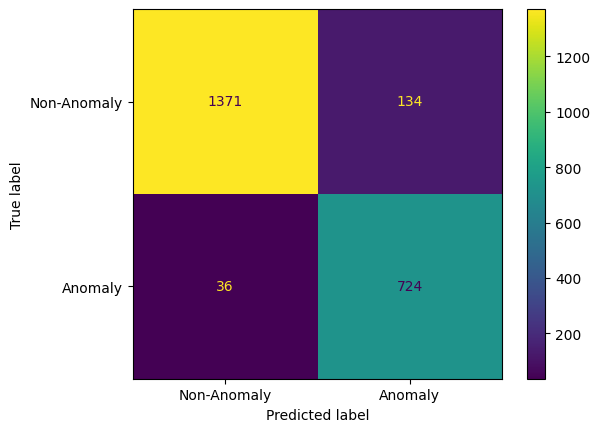

In [57]:
ConfusionMatrixDisplay.from_predictions(accu_y_val, accu_y_pred, display_labels=["Non-Anomaly", "Anomaly"])

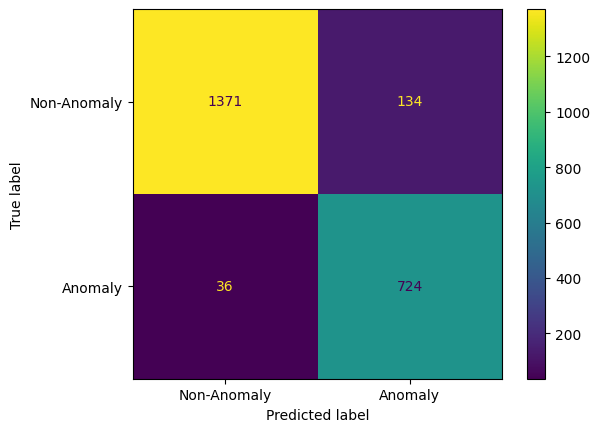

In [58]:
ConfusionMatrixDisplay.from_predictions(accu_y_val, accu_y_pred, display_labels=["Non-Anomaly", "Anomaly"])

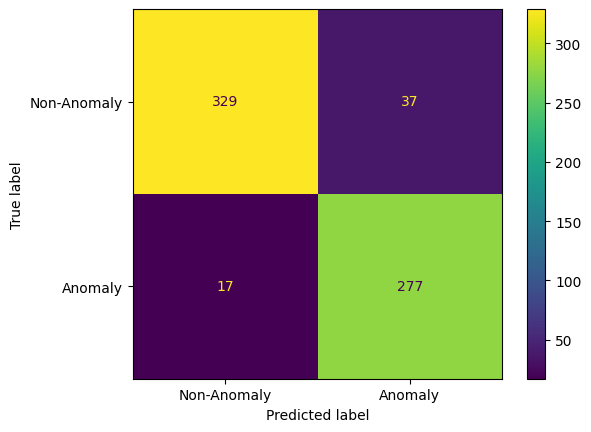

In [59]:
ConfusionMatrixDisplay.from_predictions(redeem_y_val, redeem_y_pred, display_labels=["Non-Anomaly", "Anomaly"])

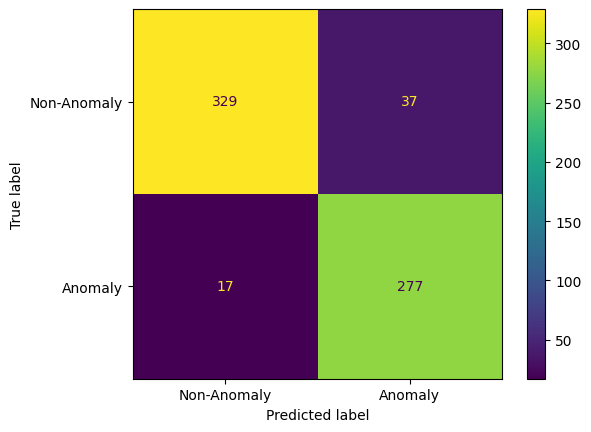

In [60]:
ConfusionMatrixDisplay.from_predictions(redeem_y_val, redeem_y_pred, display_labels=["Non-Anomaly", "Anomaly"])

# Mock DB

In [61]:
def create_mock_db(df, prefix):
    mock_df = df.copy()
    mock_df = basic_preprocess(mock_df)
    mock_df = sort_by_user_time(mock_df)

    mock_train, mock_val = split_per_user(mock_df, split_ratio=SPLIT_RATIO)

    mock_train.drop(columns=['is_anomaly'], errors='ignore').to_csv(f"Mock_db/mock_train_{prefix}.csv", encoding='utf-8', index=False)
    mock_val.drop(columns=['is_anomaly'], errors='ignore').to_csv(f"Mock_db/mock_val_{prefix}.csv", encoding='utf-8', index=False)


In [62]:
raw_accu_df = pd.read_csv("Datasets/synthetic_accural_data.csv")
raw_redeem_df = pd.read_csv("Datasets/synthetic_redeem_data.csv")

create_mock_db(raw_accu_df, "accu")
create_mock_db(raw_redeem_df, "redeem")